<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Decision Tree**


A decision tree makes predictions using a set of if-else rules. Each prediction follows a path from the root node to a leaf node. Because this rule-based structure is easy to follow, decision trees are highly interpretable.
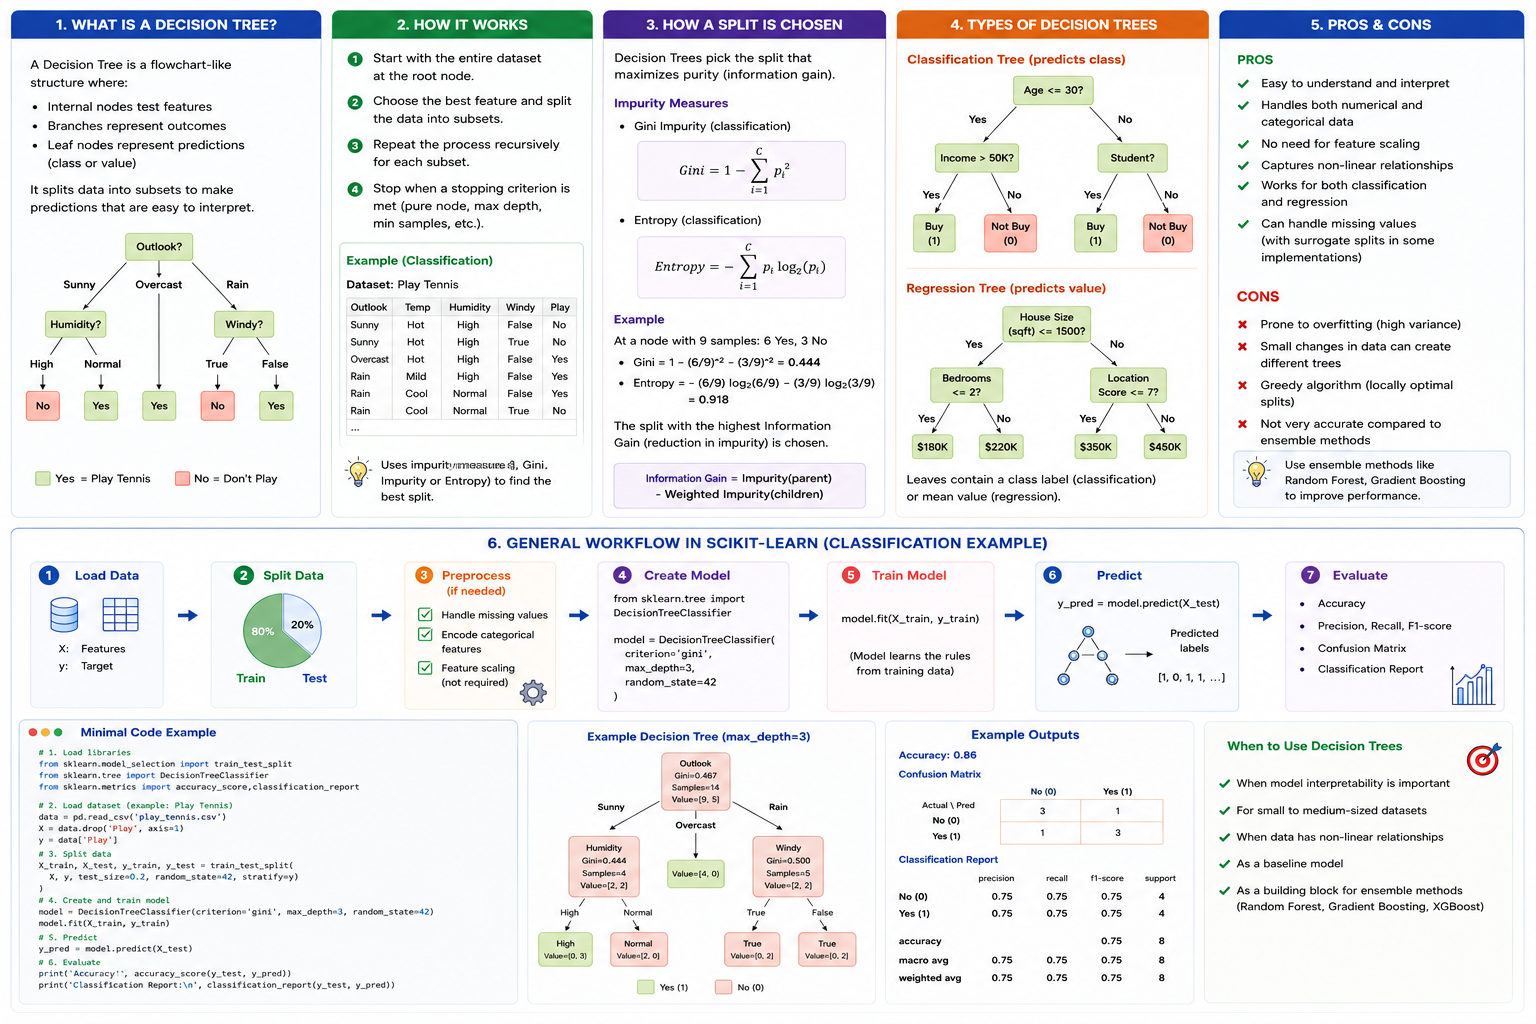

## **Introduction**

A decision tree predicts by sending a sample through a sequence of if-else rules. At each internal node, the tree checks one feature against a threshold:

$$
x_j \leq t
$$

Here, $x_j$ is one feature and $t$ is the split threshold. If the condition is true, the sample goes to the left child node. If it is false, the sample goes to the right child node.

When the sample reaches a leaf node, the tree predicts the majority class in that leaf:

$$
\hat{y} = \arg\max_k p_k
$$

Here, $p_k$ is the proportion of training samples in the leaf that belong to class $k$.

During training, the tree chooses splits that make the child nodes as pure as possible. A pure node mostly contains samples from one class. Two common impurity cost functions are **Gini impurity** and **entropy**.

**Gini impurity** is:

$$
Gini = 1 - \sum_k p_k^2
$$

**Entropy** is:

$$
Entropy = -\sum_k p_k \log_2(p_k)
$$

For each possible split, the tree calculates the weighted impurity of the left and right child nodes:

$$
Cost = \frac{n_{left}}{n}I_{left} + \frac{n_{right}}{n}I_{right}
$$

Here, $I$ can be Gini impurity or entropy. The tree chooses the split with the lowest cost, which means the child nodes are more pure.


## **Objectives**
We will use a tumor sample dataset that contains lab test results (the same dataset used in lab **3.2.1**). The objective is to classify each tumor as benign or malignant. This is a binary classification task because the target has two possible classes.


* Train decision tree models with customized hyperparameters
* Evaluate decision tree models for a classification task
* Visualize decision tree models by plotting the tree structure
* Tune hyperparameters to find the best model for this dataset


----


## **Workflow**
### **Set Up the Lab Environment**


Install and import the required packages.


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import metrics
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier



In [3]:
rs = 123

### **Load and Explore the Tumor Dataset**


First, load the tumor dataset as a Pandas DataFrame.


In [4]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/tumor.csv"
tumor_df = pd.read_csv(dataset_url)

Next, look at the first few rows of the DataFrame.


In [5]:
tumor_df.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


Each row in this dataset represents one tumor sample. The feature columns contain lab test results, such as clump thickness and cell shape. The target variable is `Class`, where the goal is to predict whether the tumor is benign or malignant.


Next, split the DataFrame into training and testing sets.


In [6]:
# Get the input features
X = tumor_df.iloc[:, :-1]
# Get the target variable
y = tumor_df.iloc[:, -1]

<Axes: xlabel='Class'>

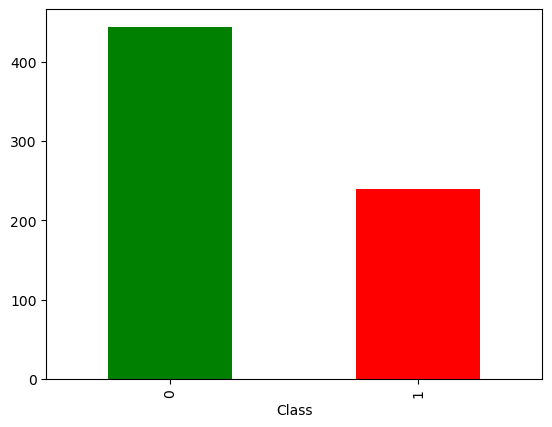

In [ ]:
y.value_counts().plot.bar(color=["green", "red"])

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=rs
)

### **Train a default decision tree**


Training a decision tree classifier with `sklearn` is straightforward. First, define a `DecisionTreeClassifier` object. In this first model, we will use the default settings.


In [9]:
# Train a decision tree with default settings
model = DecisionTreeClassifier(random_state=rs)

Train the decision tree model with the training data.


In [10]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Next, make predictions on the test data.


In [11]:
preds = model.predict(X_test)

The function below evaluates the trained decision tree model using common classification metrics.


In [ ]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos["accuracy"] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(
        yt, yp, average="binary"
    )
    results_pos["recall"] = recall
    results_pos["precision"] = precision
    results_pos["f1score"] = f_beta
    return results_pos

In [13]:
evaluate_metrics(y_test, preds)

{'accuracy': 0.9562043795620438,
 'recall': 0.9583333333333334,
 'precision': 0.92,
 'f1score': 0.9387755102040817}

The default decision tree model performs very well on the test data, with an F1-score of about `0.94`. Next, we will visualize and interpret the trained tree.


### **Visualize the Trained Decision Tree**


We will use the `tree.plot_tree()` method from `sklearn` to plot the decision tree.


In [ ]:
def plot_decision_tree(model, feature_names):
    plt.subplots(figsize=(25, 20))
    tree.plot_tree(model, feature_names=feature_names, filled=True)
    plt.show()

In [15]:
feature_names = X.columns.values

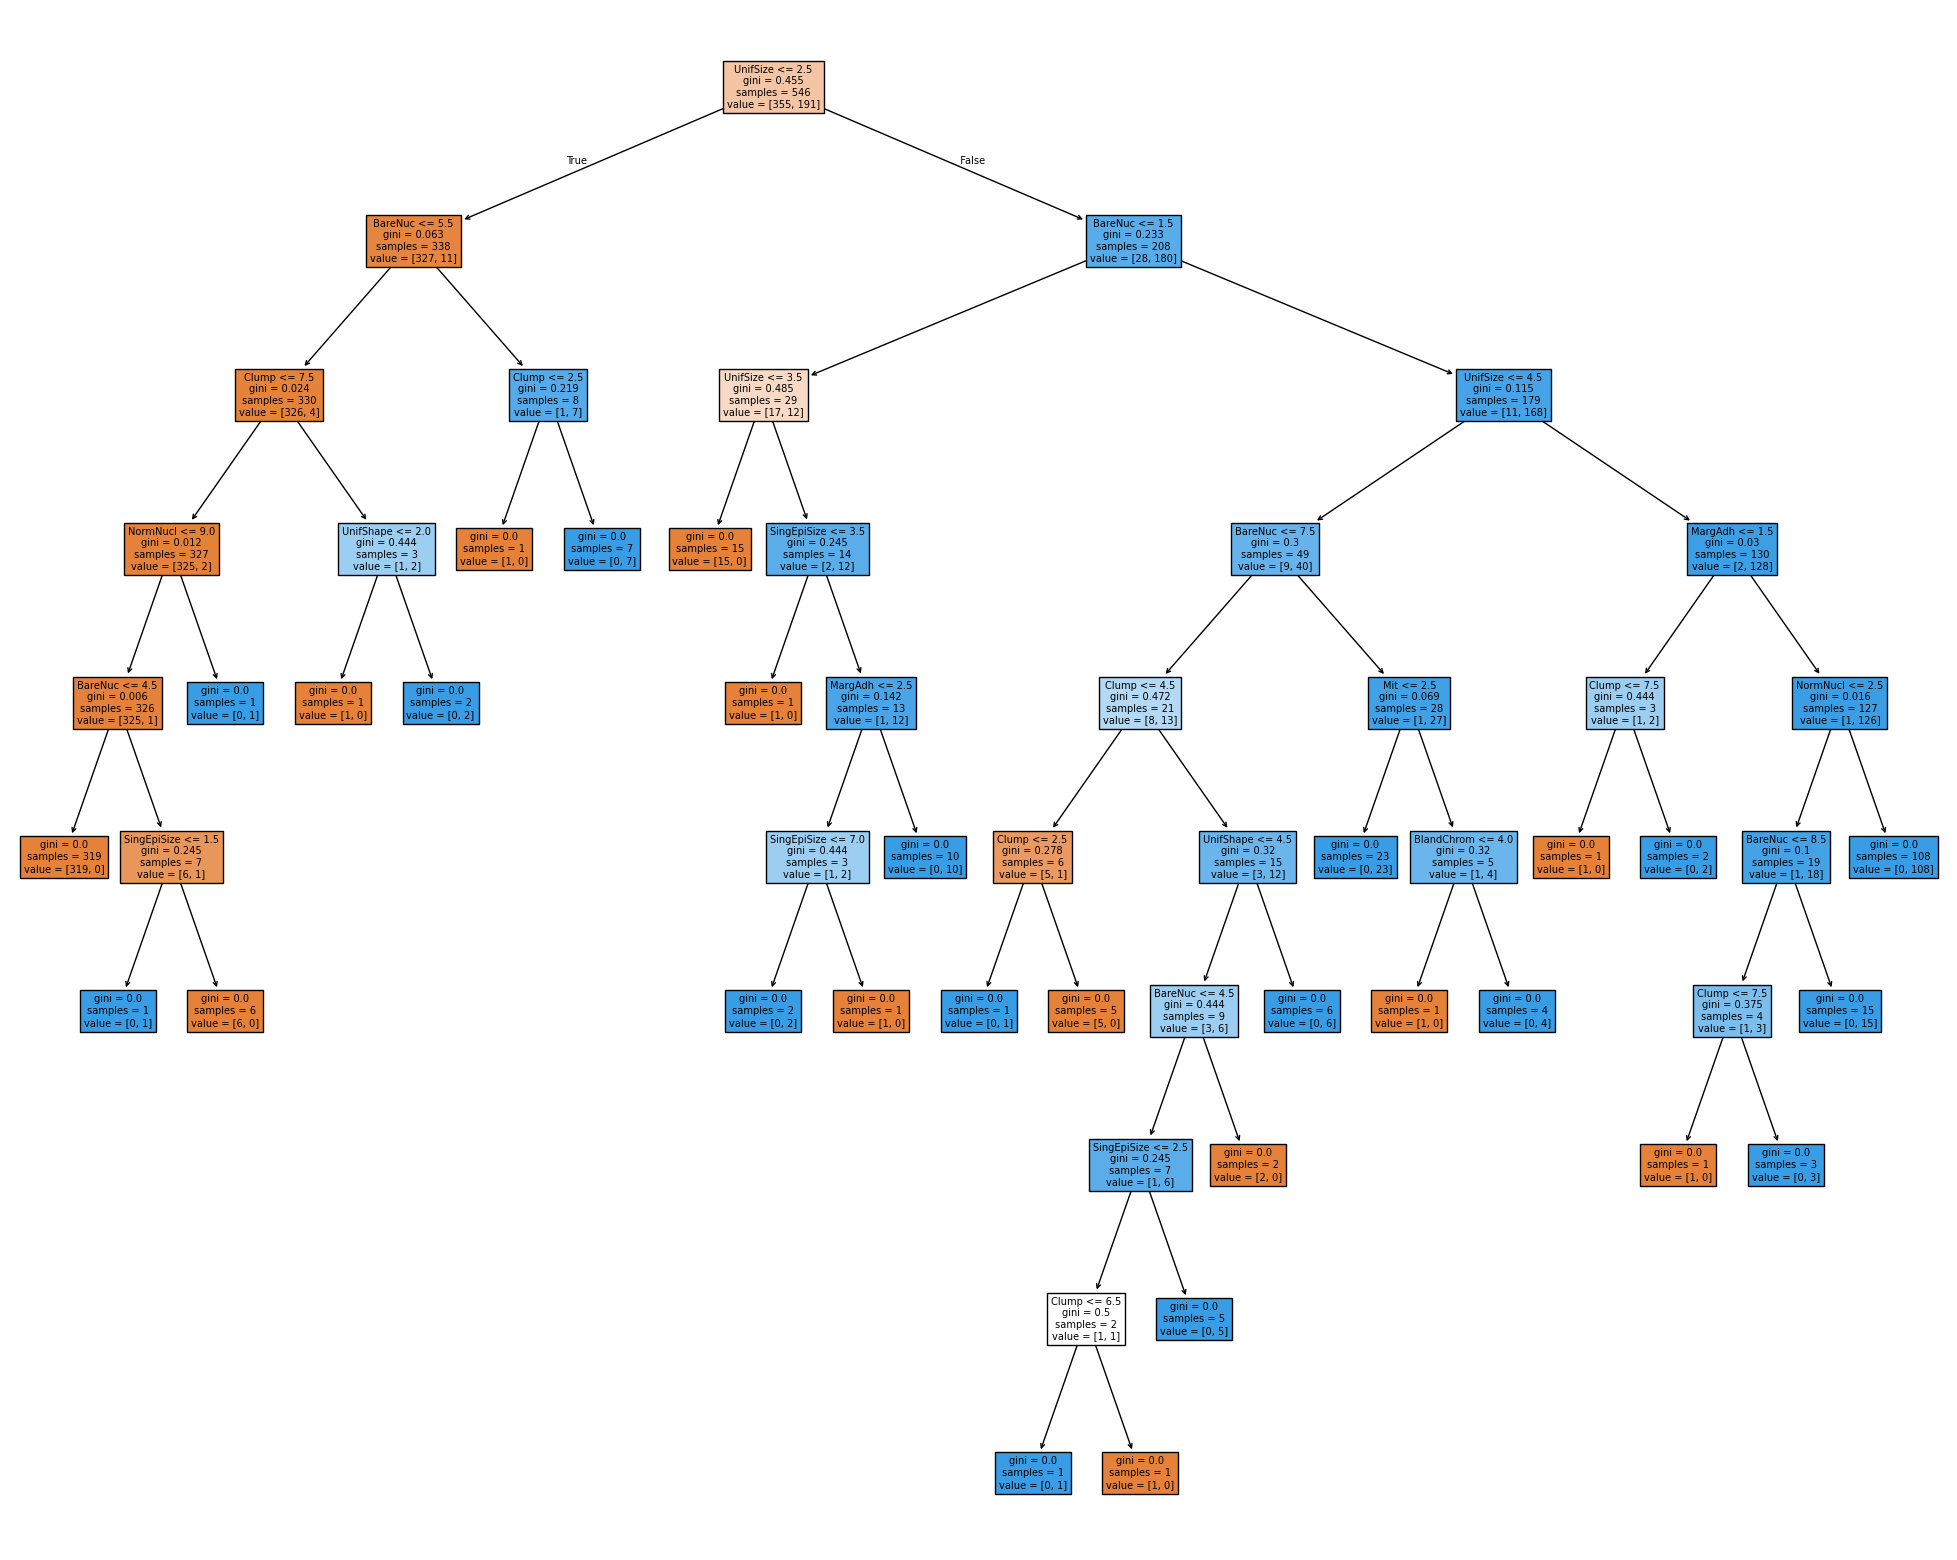

In [16]:
plot_decision_tree(model, feature_names)

The plot shows a fairly complex decision tree. The node colors show the majority class in each node: orange means most samples are `Class 0`, blue means most samples are `Class 1`, and white means the node has a similar number of samples from both classes.


Because the tree is large, the rules and split thresholds are difficult to read. Large decision trees can also have high variance and may overfit the training data. Next, we will build simpler decision trees and check whether they improve performance.


### **Customize the Decision Tree Model**


`DecisionTreeClassifier` has several hyperparameters that control the shape and complexity of the tree. Three commonly tuned hyperparameters are:

- `criterion`: The rule used to measure split quality, such as `gini` or `entropy`
- `max_depth`: The maximum depth of the tree. A larger depth usually creates a more complex model.
- `min_samples_leaf`: The minimum number of samples required in each leaf node. A larger value usually creates a simpler tree.


First, try the following hyperparameter values:

- `criterion='entropy'`
- `max_depth=10`
- `min_samples_leaf=3`


In [ ]:
# criterion = 'entropy'
# max_depth = 10
# min_samples_leaf = 3
custom_model = DecisionTreeClassifier(
    criterion="entropy", max_depth=10, min_samples_leaf=3, random_state=rs
)

Train and evaluate the customized decision tree model.


In [18]:
custom_model.fit(X_train, y_train)
preds = custom_model.predict(X_test)
evaluate_metrics(y_test, preds)

{'accuracy': 0.9635036496350365,
 'recall': 0.9166666666666666,
 'precision': 0.9777777777777777,
 'f1score': 0.946236559139785}

The F1-score increases to about `0.946`, which is slightly better than the default decision tree model.


Next, visualize the customized model using the `plot_decision_tree()` helper function created earlier.


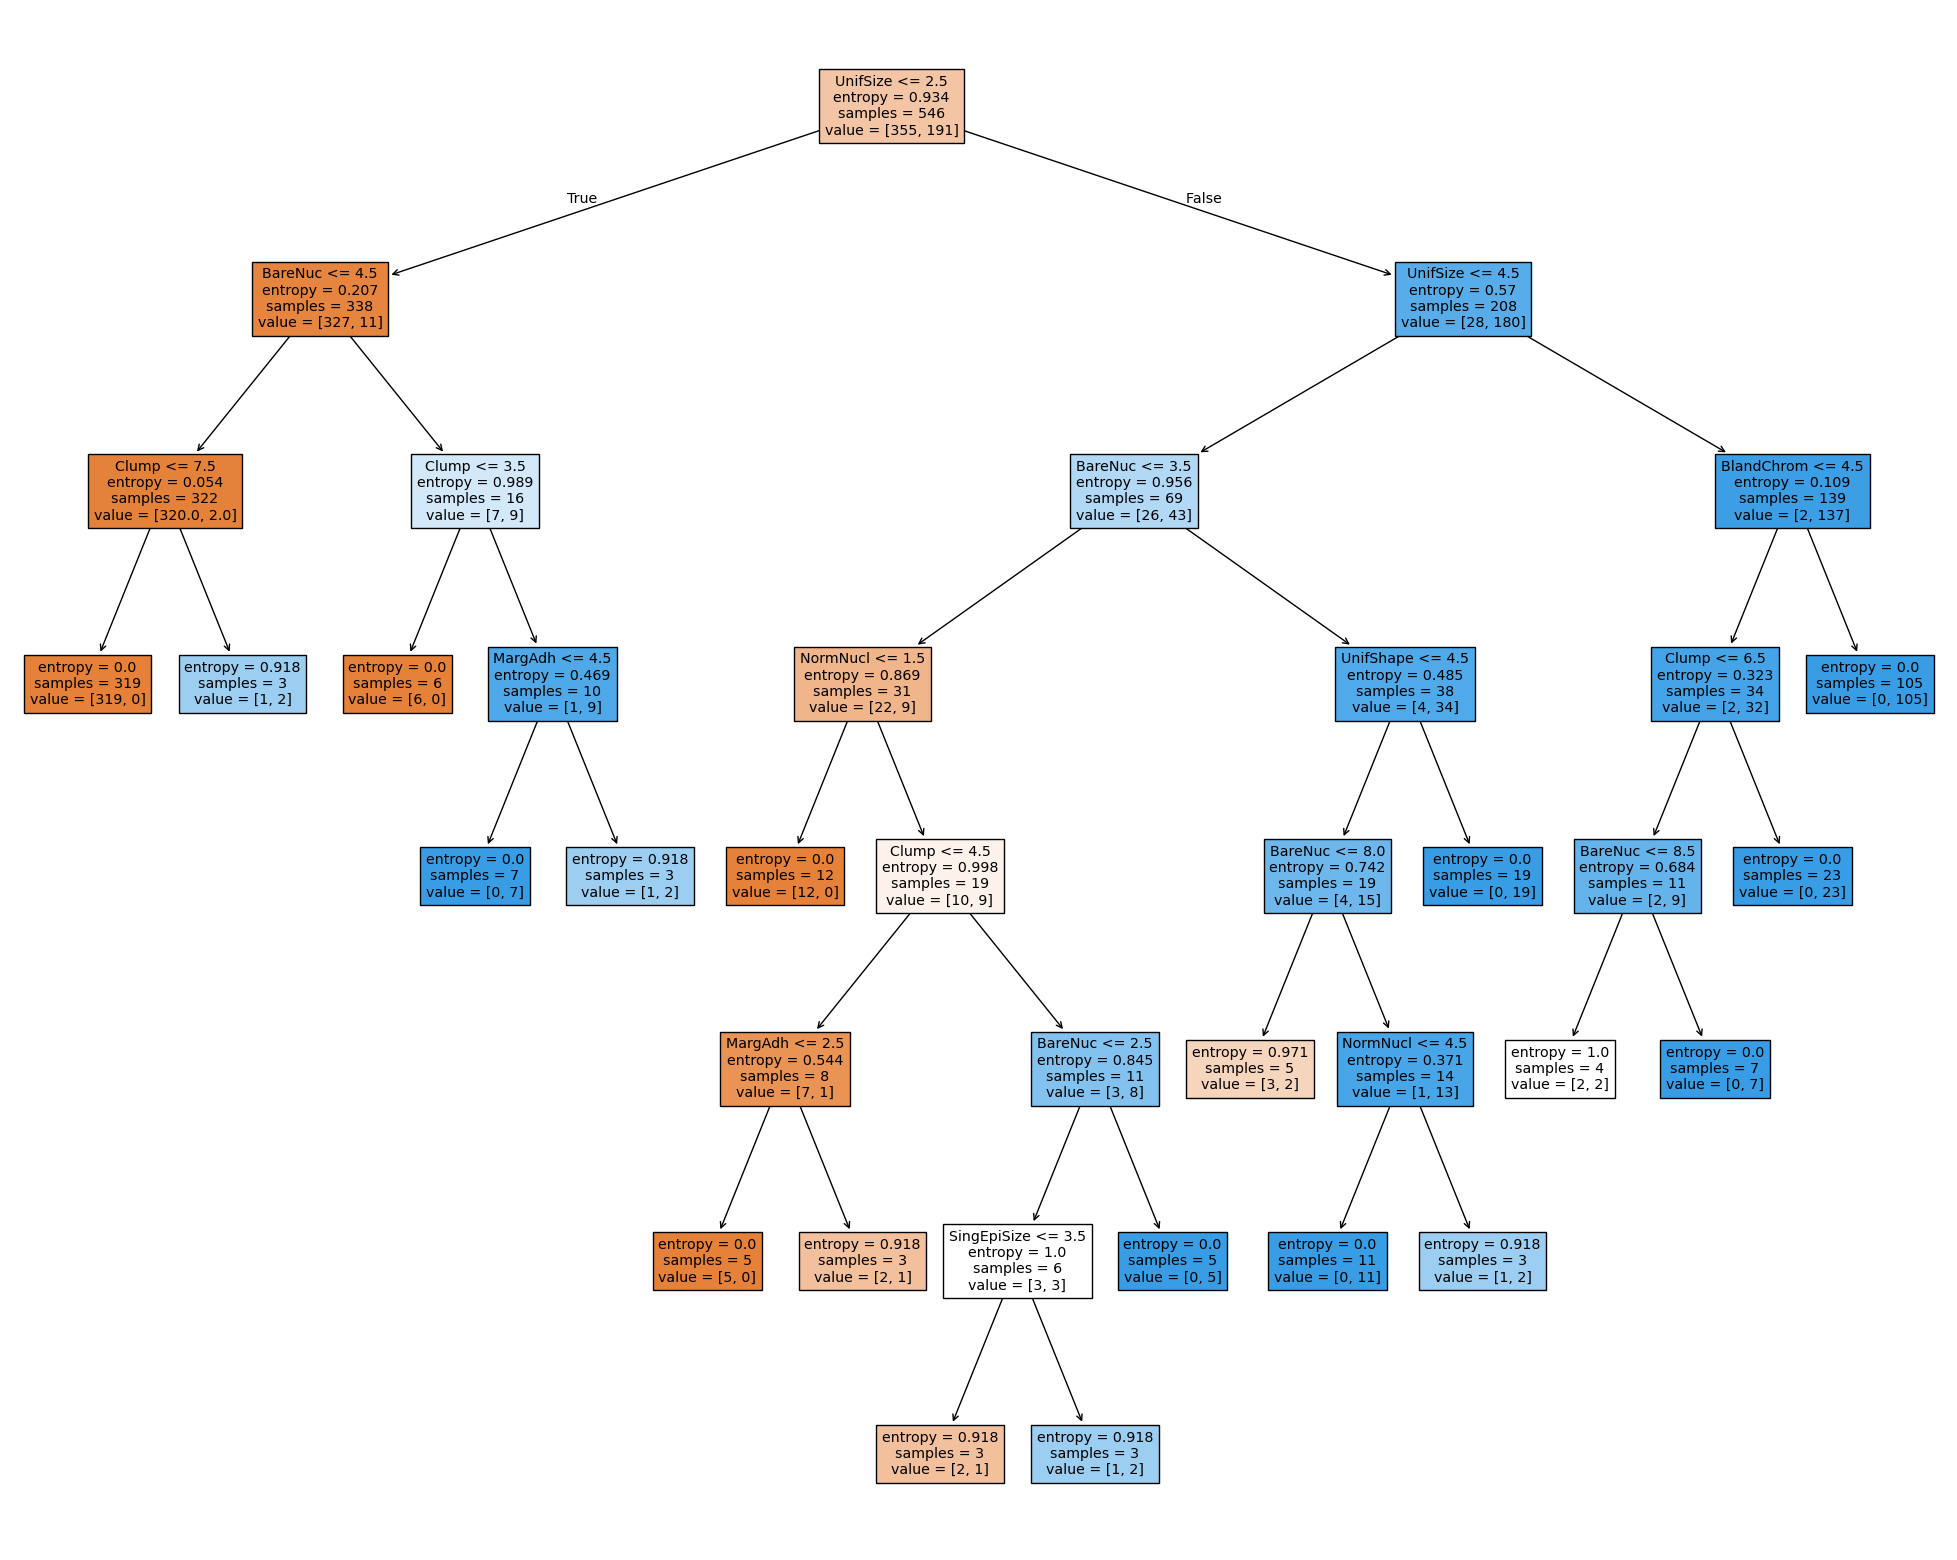

In [19]:
# Plot the decision tree
plot_decision_tree(custom_model, feature_names)

The customized decision tree is much simpler than the default tree. Each node shows the split feature, split threshold, entropy value, sample count, class counts, and predicted class.


### **Coding Exercise**

Build and visualize a decision tree with `criterion='gini'`, `max_depth=15`, and `min_samples_leaf=5`.


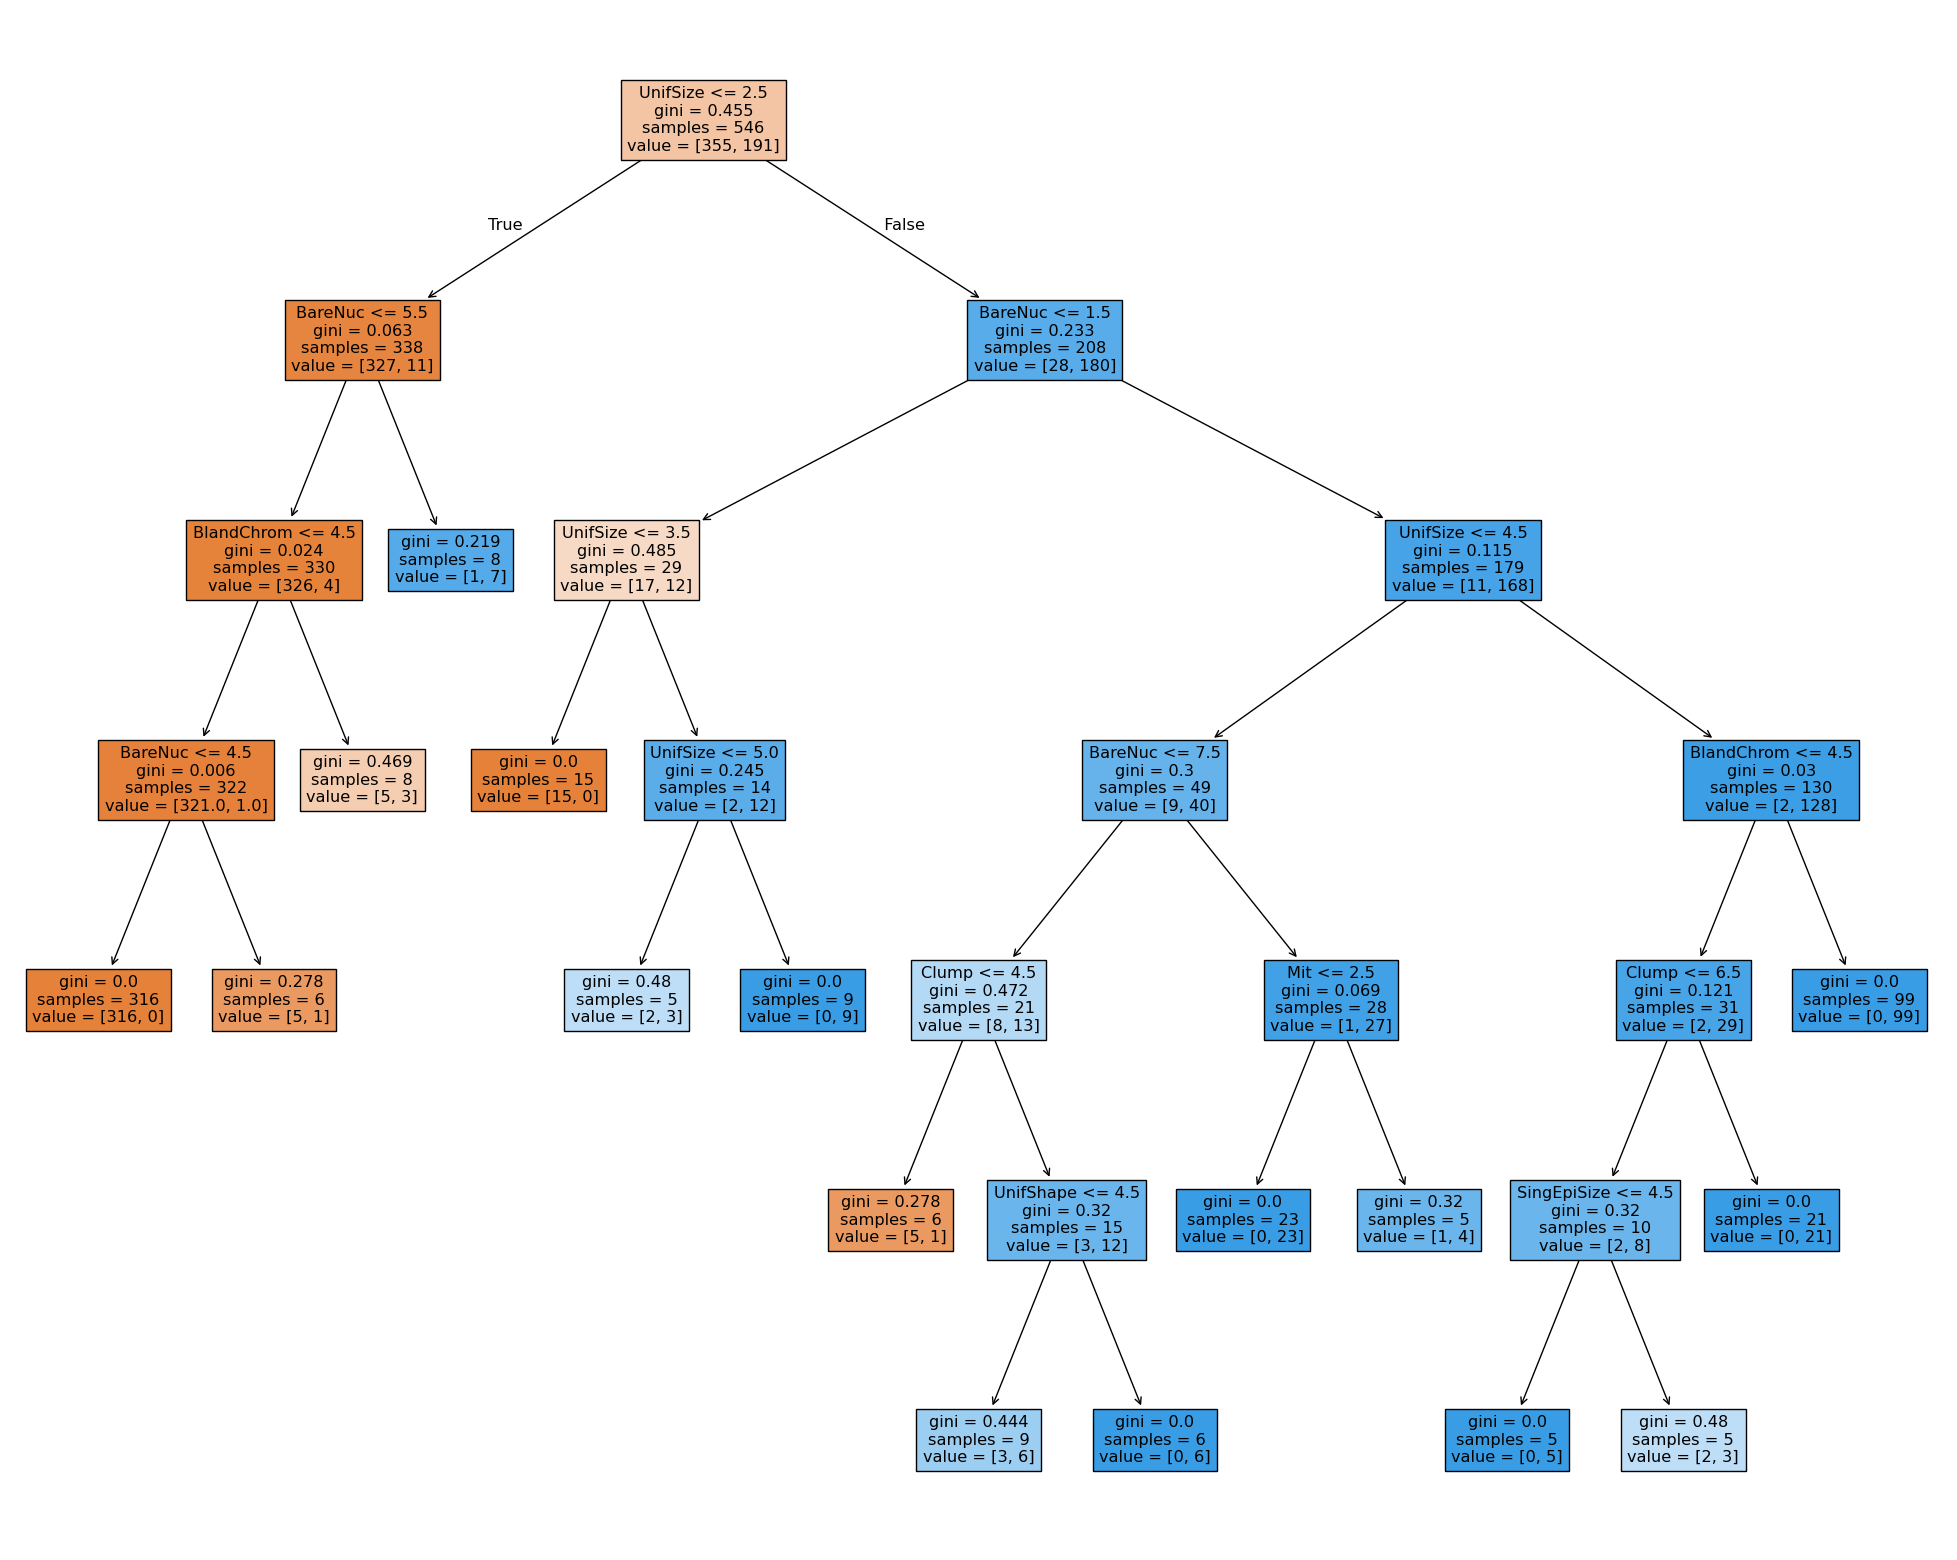

In [ ]:
# Train a decision tree with the specified hyperparameters
custom_model = DecisionTreeClassifier(
    criterion="gini", max_depth=15, min_samples_leaf=5, random_state=rs
)
custom_model.fit(X_train, y_train)
preds = custom_model.predict(X_test)
evaluate_metrics(y_test, preds)
# Plot the decision tree
plot_decision_tree(custom_model, feature_names)

### **Tune Hyperparameters**


Finally, use GridSearchCV with cross-validation to find the hyperparameters that produce the highest F1-score.


First, define a `params_grid` dictionary with the candidate parameter values.


In [ ]:
params_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5],
}

Next, create a default decision tree classifier to tune.


In [22]:
model = DecisionTreeClassifier(random_state=rs)

Now use `GridSearchCV` to search for the parameters that produce the highest F1-score.

Because this is a classification task, we use `StratifiedKFold` for cross-validation. It keeps the class proportions similar in each fold, so each fold better represents the full dataset. We also set `shuffle=True` to randomly shuffle the data before creating folds. This helps avoid folds that depend on the original row order.

For regression tasks, use `KFold` instead. Regression targets are continuous values, so there are no class proportions to preserve.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

grid_search = GridSearchCV(
    estimator=model, param_grid=params_grid, scoring="f1", cv=cv, verbose=1
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [24]:
best_params

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2}

The best parameters are `criterion='gini'`, `max_depth=10`, and `min_samples_leaf=5`.


### **Coding Exercise** 

Build and visualize a decision tree with the best parameters from GridSearchCV.


In [ ]:
## Train a decision tree with the specified hyperparameters
best_model = DecisionTreeClassifier(**best_params, random_state=rs)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
evaluate_metrics(y_test, preds)

{'accuracy': 0.948905109489051,
 'recall': 0.8958333333333334,
 'precision': 0.9555555555555556,
 'f1score': 0.9247311827956989}

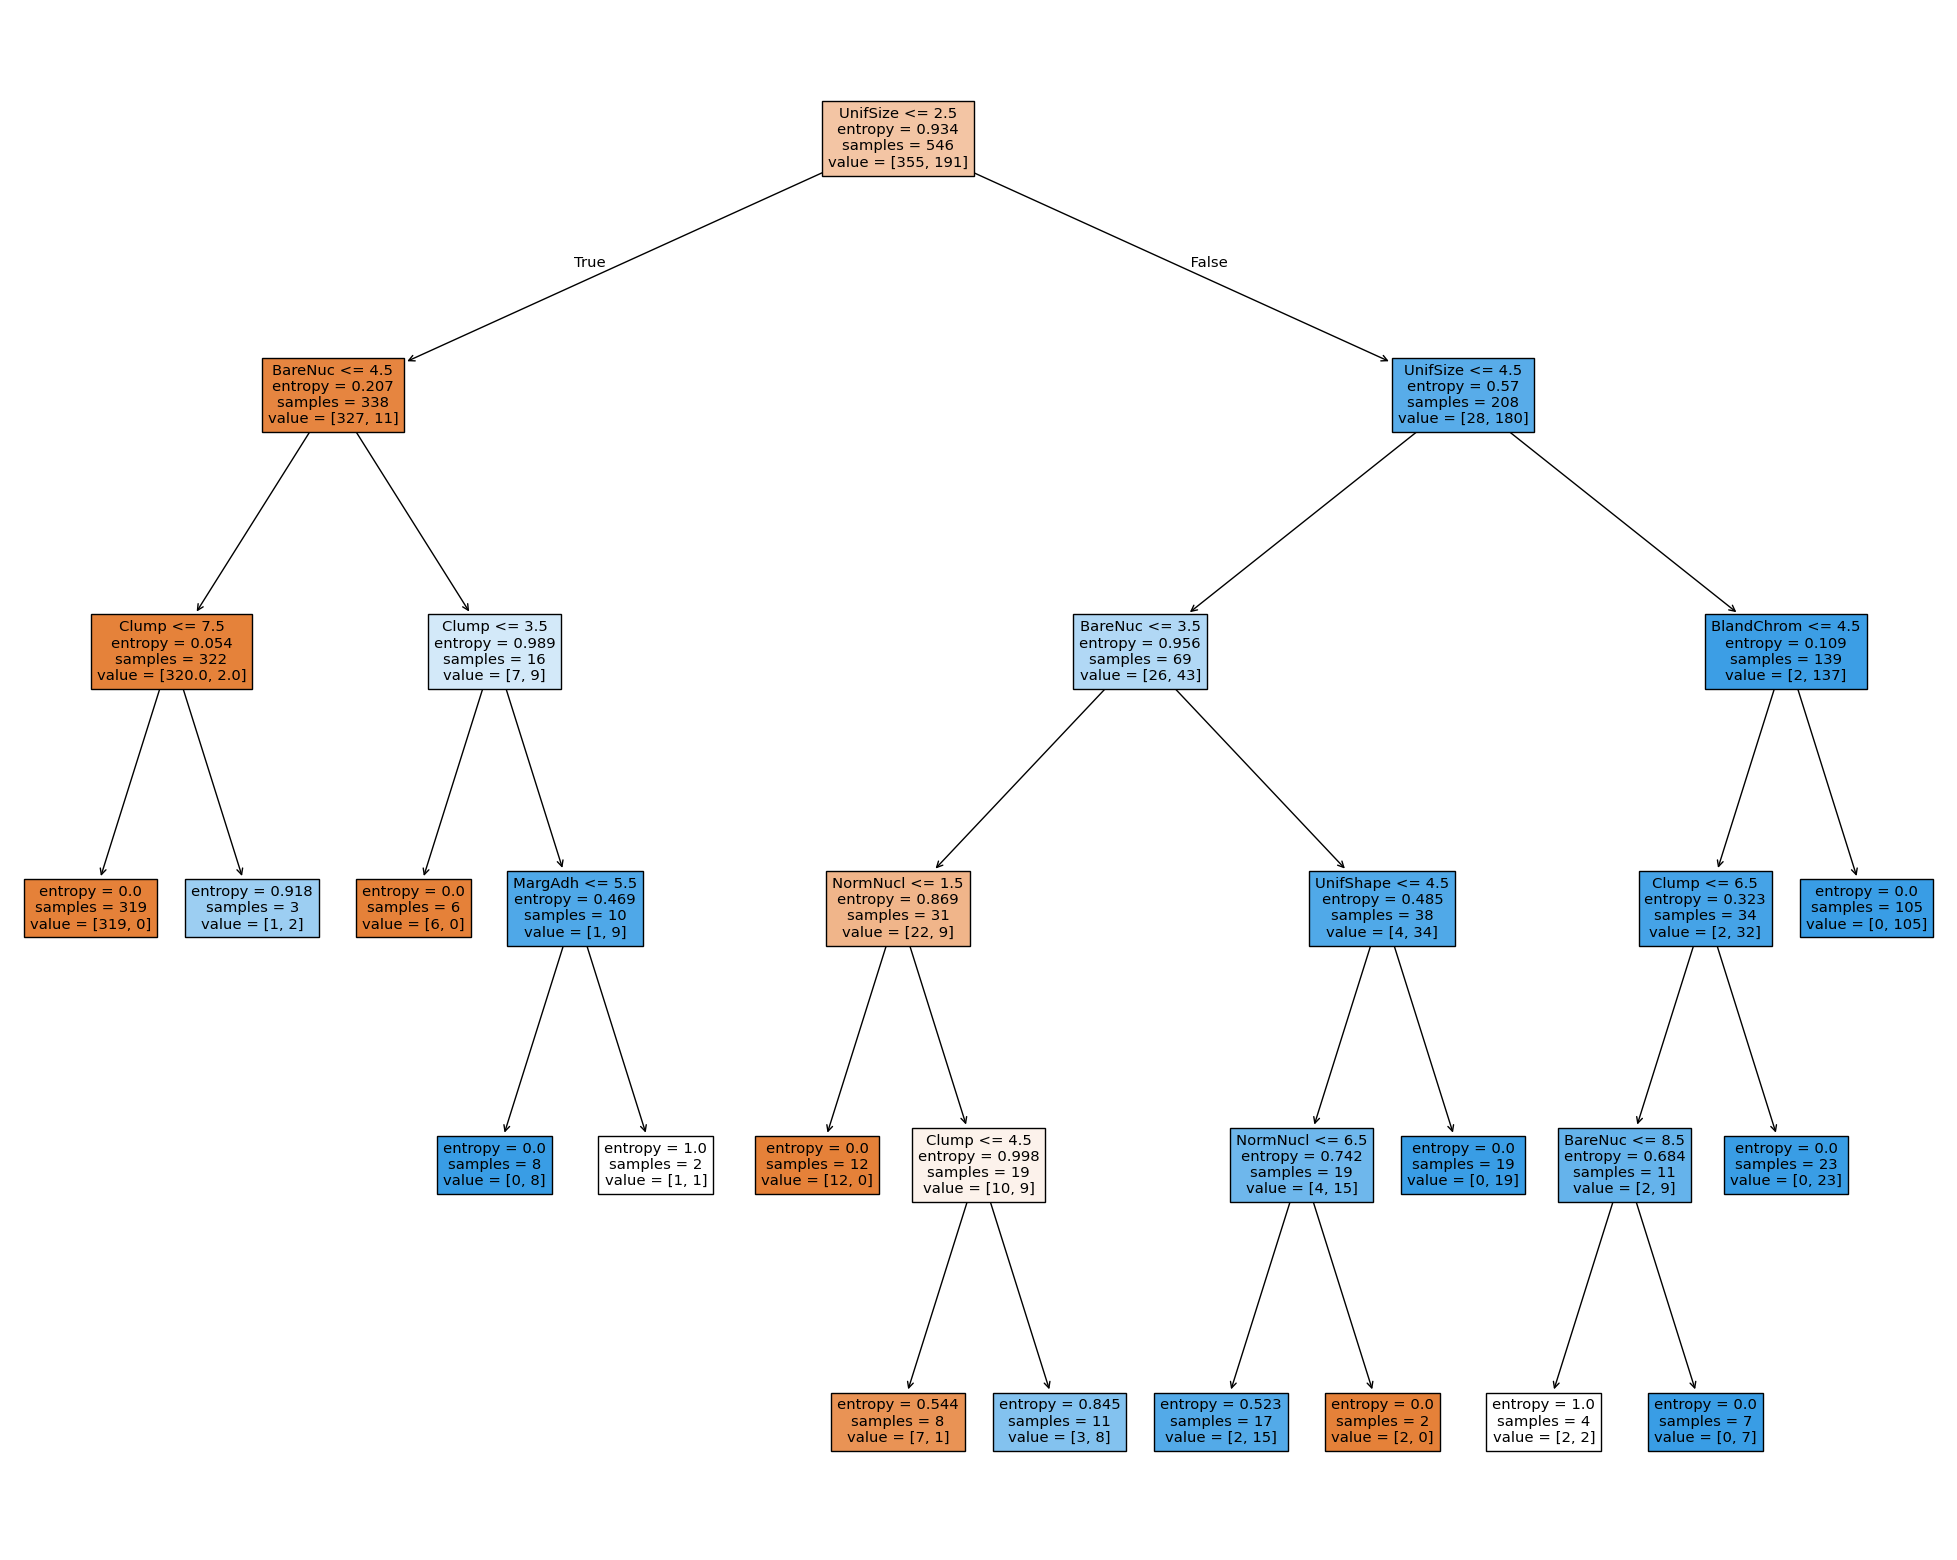

In [28]:
# Plot the decision tree
plot_decision_tree(best_model, feature_names)

## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/), Su Wu


<!--## Change Log--!>


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-9-23|1.0|Yan|Created the initial version||2022-2-9|1.1|Steve Hord|QA pass|
--!>


Copyright © 2021 IBM Corporation. All rights reserved.
